### OPEN QASM 

https://quantum.cloud.ibm.com/docs/es/guides/introduction-to-qasm

OpenQASM (lenguaje ensamblador cuántico abierto), una interfaz de programación independiente de la máquina compatible con las QPU de IBM®, es un lenguaje de programación imperativo para la descripción de circuitos cuánticos. OpenQASM utiliza el modelo de circuito cuántico para expresar programas cuánticos como secuencias ordenadas de operaciones parametrizadas (como puertas, mediciones y reinicios) y computación clásica en tiempo real. Además de algoritmos cuánticos, OpenQASM puede describir circuitos diseñados para caracterizar, validar o depurar procesadores cuánticos.

A medida que las necesidades del desarrollo de QPU han evolucionado, la lista de características de OpenQASM se ha ampliado en respuesta; la última versión, OpenQASM 3, incorpora extensiones que incluyen control de flujo de avance clásico, modificadores de puerta e implementaciones de pulsos.

https://arxiv.org/abs/2104.14722

OpenQASM es la opción preferida por diversos públicos gracias a su versatilidad. La introducción al documento 1 de OpenQASM 3 ofrece ejemplos:

Aunque OpenQASM no es un lenguaje de alto nivel, muchos usuarios desean escribir circuitos cuánticos simples a mano utilizando un lenguaje expresivo específico del dominio. Los investigadores que estudian la compilación de circuitos necesitan información de alto nivel registrada en las representaciones intermedias para fundamentar los algoritmos de optimización y síntesis. Los experimentalistas prefieren la comodidad de escribir circuitos a un nivel relativamente alto, pero a menudo necesitan modificar manualmente las descripciones de temporización o de puertas a nivel de pulso en varios puntos del circuito. Los ingenieros de hardware que diseñan los controladores clásicos y los generadores de formas de onda prefieren lenguajes que sean fáciles de compilar dadas las limitaciones del hardware y que creen una estructura de circuito explícita que los controladores puedan aprovechar.

OpenQASM es el formato de intercambio común entre herramientas de software cuántico independientes. Para los desarrolladores que prefieren una herramienta para la construcción de circuitos, otra para la transpilación, etc., OpenQASM es la lengua franca que actúa como puente entre ellas.

El SDK de Qiskit proporciona formas de convertir entre OpenQASM y la QuantumCircuitclase (consulte OpenQASM 2 y Qiskit y OpenQASM 3 y Qiskit para obtener instrucciones).

https://quantum.cloud.ibm.com/docs/es/guides/interoperate-qiskit-qasm2

https://quantum.cloud.ibm.com/docs/es/guides/interoperate-qiskit-qasm3

Para obtener más información, consulte la especificación en vivo de OpenQASM.

# Importar un programa OpenQASM2 a Qiskit

Dos funciones importan programas OpenQASM 2 a Qiskit. Estas son qasm2.load(), que toma un nombre de archivo, y qasm2.loads(), que toma el programa OpenQASM 2 como una cadena.

import qiskit.qasm2
 
qiskit.qasm2.load(filename, include_path=('.',), include_input_directory='append', custom_instructions=(), custom_classical=(), strict=False)
qiskit.qasm2.loads(program, include_path=('.',), custom_instructions=(), custom_classical=(), strict=False)

Importamos a Qiskit un programa en QASM2 como una cadena para ejecutarlo dentro de Qiskit

Utilizamos loads o load string.

In [5]:
import qiskit.qasm2
 
program = """
    OPENQASM 2.0;
    include "qelib1.inc";
    qreg q[2];
    creg c[2];
 
    h q[0];
    cx q[0], q[1];
 
    measure q -> c;
"""
circuit = qiskit.qasm2.loads(program)
circuit.draw()

┌───┐     ┌─┐   
q_0: ┤ H ├──■──┤M├───
     └───┘┌─┴─┐└╥┘┌─┐
q_1: ─────┤ X ├─╫─┤M├
          └───┘ ║ └╥┘
c: 2/═══════════╩══╩═
                0  1

# Importamos un programa OpenQASM3 a Qiskit

Como fichero o como cadena.

!pip install qiskit-qasm3-import

import qiskit.qasm3

qiskit.qasm3.load(file_name)

qiskit.qasm3.loads(program_string)

In [ ]:
!pip install qiskit-qasm3-import

### Como fichero con load

In [2]:
import qiskit.qasm3

qiskit.qasm3.load("ejemploOpenQasmBasico.qasm")

### Como cadena con loads

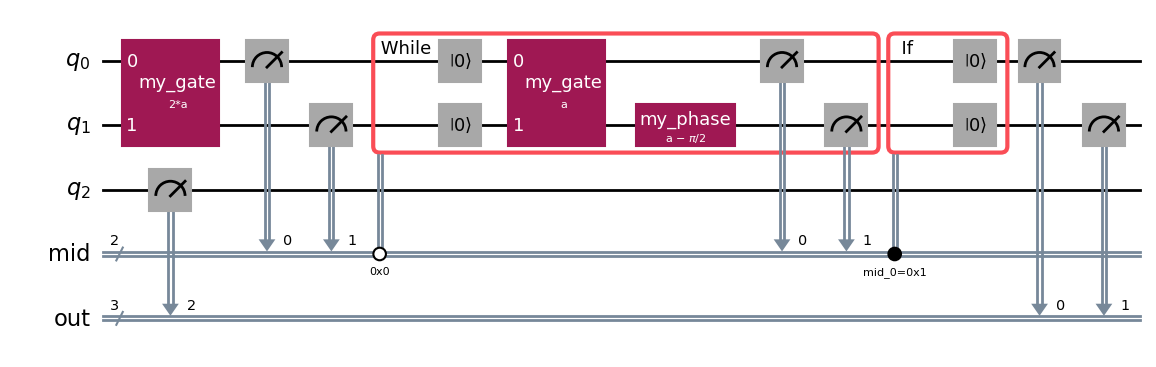

In [3]:
import qiskit.qasm3
 
program = """
    OPENQASM 3.0;
    include "stdgates.inc";
 
    input float[64] a;
    qubit[3] q;
    bit[2] mid;
    bit[3] out;
 
    let aliased = q[0:1];
 
    gate my_gate(a) c, t {
      gphase(a / 2);
      ry(a) c;
      cx c, t;
    }
    gate my_phase(a) c {
      ctrl @ inv @ gphase(a) c;
    }
 
    my_gate(a * 2) aliased[0], q[{1, 2}][0];
    measure q[0] -> mid[0];
    measure q[1] -> mid[1];
 
    while (mid == "00") {
      reset q[0];
      reset q[1];
      my_gate(a) q[0], q[1];
      my_phase(a - pi/2) q[1];
      mid[0] = measure q[0];
      mid[1] = measure q[1];
    }
 
    if (mid[0]) {
      let inner_alias = q[{0, 1}];
      reset inner_alias;
    }
 
    out = measure q;
"""
circuit = qiskit.qasm3.loads(program)
circuit.draw("mpl")

## Exportar un circuito de Qiskit a OpenQASM2

In [4]:
from qiskit import QuantumCircuit, qasm2
 
# Define any circuit.
circuit = QuantumCircuit(2, 2)
circuit.h(0)
circuit.cx(0, 1)
circuit.measure([0, 1], [0, 1])
 
# Export to a string.
program = qasm2.dumps(circuit)
 
# Export to a file.
qasm2.dump(circuit, "my_file.qasm")

## Exportar un circuito de Qiskit a OpenQASM3

In [5]:
from qiskit import QuantumCircuit
from qiskit.qasm3 import dumps
 
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()
 
dumps(qc)

'OPENQASM 3.0;\ninclude "stdgates.inc";\nbit[2] meas;\nqubit[2] q;\nh q[0];\ncx q[0], q[1];\nbarrier q[0], q[1];\nmeas[0] = measure q[0];\nmeas[1] = measure q[1];\n'

Lo mismo pero guardando en un fichero

In [6]:
from qiskit import QuantumCircuit
from qiskit.qasm3 import dump
 
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()
 
f = open("my_file.txt", "w")
dump(qc, f)
f.close()

## Ejemplos de ejecución de qasm mediante qsharp dentro de un código qiskit. 

In [1]:
# Qsharp es un lenguaje de programación cuántica desarrollado por Microsoft, 
# diseñado para escribir algoritmos cuánticos y simular circuitos cuánticos.
# Mediante qsharp.openqasm puedo ejecutar programas en OpenQASM, un lenguaje de descripción 
# de circuitos cuánticos creado por IBM y utilizado para describir circuitos cuánticos
# de manera estándar. OpenQASM es ampliamente utilizado en la comunidad cuántica para
# representar y compartir circuitos cuánticos, y es compatible con varios simuladores y
# plataformas cuánticas.
# Este script inicializa el entorno de Qsharp y configura el perfil de destino para
# ejecutar programas cuánticos utilizando OpenQASM. También importa las bibliotecas necesarias
# para trabajar con ruido de bit flip y perfiles de destino específicos.      
import qsharp
from qsharp import BitFlipNoise, TargetProfile
from qsharp.openqasm import run

# Mediante qsharp.openqasm puedo ejecutar programas en OpenQASM, un lenguaje de descripción
# de circuitos cuánticos creado por IBM y utilizado para describir circuitos cuánticos
# de manera estándar. OpenQASM es ampliamente utilizado en la comunidad cuántica para
# representar y compartir circuitos cuánticos, y es compatible con varios simuladores y plataformas cuánticas.
# Este script inicializa el entorno de Qsharp y configura el perfil de destino para
# ejecutar programas cuánticos utilizando OpenQASM. También importa las bibliotecas necesarias
# para trabajar con ruido de bit flip y perfiles de destino específicos.
qsharp.init(target_profile=TargetProfile.Base)

Q# initialized with configuration: {'targetProfile': 'base', 'languageFeatures': None, 'manifest': None}

Mediante el método run, puedo ejecutar desde Qiskit el código de QASM
a través del método run de la libreria qshar.qasm

In [ ]:
# stdgates.inc es un archivo de inclusión que contiene definiciones de puertas cuánticas estándar
# utilizadas en circuitos cuánticos. Este archivo es parte de la biblioteca estándar de Qsharp y
# proporciona una forma conveniente de acceder a las puertas cuánticas comunes sin tener que
# definirlas manualmente en cada programa. Al incluir "stdgates.inc", se pueden utilizar
# puertas como Hadamard, CNOT, y otras sin necesidad de definirlas explícitamente. 

# Este script ejecuta un circuito cuántico simple que aplica una puerta Hadamard a un qubit,
# seguido de una puerta CNOT entre dos qubits, y mide el segundo qubit.
# El resultado de la medición se almacena en una variable llamada "c" y se
# ejecuta con un ruido de bit flip del 10% para simular errores en el circuito cuántico.
# Finalmente, se imprime el resultado de la ejecución del circuito cuántico
# con el número de disparos/ejecuciones con un número de 20.
results = run(
    """
    include "stdgates.inc";
    qubit[2] q;
    reset q;
    h q[0];
    cx q[0], q[1];
    bit c = measure q[1];
    """,
    shots=20,
    noise=BitFlipNoise(0.1),
)
print(results)

[One, Zero, One, One, One, Zero, Zero, Zero, Zero, Zero, One, Zero, Zero, One, One, Zero, Zero, Zero, One, One]


Otro ejemplo de ejecución de qasm mediante qsharp dentro de un código qiskit. 

In [2]:
import qsharp
from qsharp import BitFlipNoise, TargetProfile
from qsharp.openqasm import run

qsharp.init(target_profile=TargetProfile.Base)

Q# initialized with configuration: {'targetProfile': 'base', 'languageFeatures': None, 'manifest': None}

In [ ]:
# La librería qelib1.inc es un archivo de inclusión que contiene definiciones de puertas cuánticas estándar
# y operaciones utilizadas en circuitos cuánticos. Este archivo es parte de la biblioteca estándar
# de Qiskit y proporciona una forma conveniente de acceder a las puertas cuánticas comunes
# sin tener que definirlas manualmente en cada programa. Al incluir "qelib1.inc", se pueden utilizar
# puertas como Hadamard, CNOT, y otras sin necesidad de definirlas explícitamente.

results = run(
    """
    OPENQASM 2.0;
    include "qelib1.inc";
    qreg q[2];
    creg c[2];
    h q[0];
    cx q[0], q[1];
    measure q[1] -> c[1];
    """,
    
    shots=10,
    noise=BitFlipNoise(0.1),
)
# con measure q[1] -> c[1]; se mide el segundo qubit y se almacena el resultado en el primer bit clásico    
# El resultado de la medición se almacena en una variable llamada "c" y se
# ejecuta con un ruido de bit flip del 10% para simular errores en el circuito cuántico.
# Finalmente, se imprime el resultado de la ejecución del circuito cuántico
# con el número de disparos/ejecuciones con un número de 10.
# results contiene el resultado de la ejecución del circuito cuántico mediante pares de qubits
# y bits clásicos. 
print(results)  

[[Zero, One], [Zero, One], [Zero, Zero], [Zero, Zero], [Zero, Zero], [Zero, One], [Zero, Zero], [Zero, One], [Zero, One], [Zero, Zero]]
